In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="D6qfOUTKfs2ctoaFoqkh")
project = rf.workspace("sahil-emcia").project("pan_ocr_detection_main")
version = project.version(1)
dataset = version.download("yolov5")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PAN_OCR_Detection_Main-1 in yolov5pytorch:: 100%|██████████| 2936/2936 [00:00<00:00, 5989.32it/s]


In [2]:
import yaml

with open(f"/content/PAN_OCR_Detection_Main-1/data.yaml") as f:
    data = yaml.safe_load(f)

data['train'] = f"/content/PAN_OCR_Detection_Main-1/train/images"
data['val'] = f"/content/PAN_OCR_Detection_Main-1/valid/images"
data['test'] = f"/content/PAN_OCR_Detection_Main-1/test/images"

with open(f"/content/PAN_OCR_Detection_Main-1/data.yaml", 'w') as f:
    yaml.dump(data, f)

In [3]:
# Install the required packages for Ultralytics YOLO and Weights & Biases
!pip install -U ultralytics wandb

# Enable W&B logging for Ultralytics
!yolo settings wandb=True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [4]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sahilagarwal19102004 (sahilagarwal19102004-upes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
from ultralytics import YOLO

# Load a YOLO model
model = YOLO("yolo12n.pt")

# Train and Fine-Tune the Model
model.train(
    data="/content/PAN_OCR_Detection_Main-1/data.yaml",
    epochs=150,
    batch=16,
    project="PAN_OCR",             # W&B project name
    name="yolov12_run",            # W&B run name
    device="cuda",                 # Use GPU
    imgsz=640,                     # Image size
    optimizer="SGD",               # Optimizer
)

100%|██████████| 5.34M/5.34M [00:00<00:00, 110MB/s]


Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PAN_OCR_Detection_Main-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

100%|██████████| 755k/755k [00:00<00:00, 26.7MB/s]

Overriding model.yaml nc=80 with nc=8

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

  8                  -1  2    689408  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 1]        
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  1     86912  ultralytics.nn.modules.block.A2C2f           [384, 128, 1, False, -1]      
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  1     24000  ultralytics.nn.modules.block.A2C2f           [256, 64, 1, False, -1]       
 15                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]  

...


150 epochs completed in 1.171 hours.
Optimizer stripped from PAN_OCR/yolov12_run/weights/last.pt, 5.5MB
Optimizer stripped from PAN_OCR/yolov12_run/weights/best.pt, 5.5MB

Validating PAN_OCR/yolov12_run/weights/best.pt...
Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,558,288 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.48it/s]


                   all        172       1292      0.983      0.991      0.989      0.727
                   DOB        172        172      0.988      0.988      0.983      0.624
           Father Name        168        168      0.988       0.99      0.995      0.644
                  Name        172        172      0.981      0.983      0.976      0.593
                   PAN        172        172      0.997          1      0.995      0.961
            PAN Number        171        171      0.987          1      0.991      0.662
                 Photo        172        172      0.997      0.994      0.995      0.861
                    QR        112        112      0.965      0.989       0.99      0.883
             Signature        153        153      0.964      0.987      0.986      0.584
Speed: 0.4ms preprocess, 5.8ms inference, 0.0ms loss, 5.3ms postprocess per image
Results saved to PAN_OCR/yolov12_run


lr/pg0,█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁
lr/pg2,▃▆███▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▇▇█████████████████████████████████████
metrics/mAP50-95(B),▁▂▃▅▆▇▇▇█▇▇▇█▇█▇████████████▇▇▇▇▇▇▇▇█▇█▇
metrics/precision(B),▁▂▆▇▇▇██▇███████████████████████████████
metrics/recall(B),▁▇▇█▇███████████████████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,██▇▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▃▄▃▃▃▃▃▃▂▃▃▂▂▂▁▂▁▁


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x797845bc2550>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,


image 1/86 /content/PAN_OCR_Detection_Main-1/test/images/01213346260037_jpg.rf.e1a846ed4b7022a981eab5a4eebba11e.jpg: 640x640 1 DOB, 1 Father Name, 1 Name, 1 PAN, 1 PAN Number, 1 Photo, 1 QR, 1 Signature, 13.8ms
image 2/86 /content/PAN_OCR_Detection_Main-1/test/images/01225511530017_jpg.rf.19952318b0334cea38d3ccc6456db473.jpg: 640x640 1 DOB, 1 Father Name, 1 Name, 1 PAN, 1 PAN Number, 1 Photo, 1 QR, 1 Signature, 16.9ms
image 3/86 /content/PAN_OCR_Detection_Main-1/test/images/01245671710014_jpg.rf.9a8f7728c4e834503e07330275e311c1.jpg: 640x640 1 DOB, 1 Father Name, 1 Name, 1 PAN, 1 PAN Number, 1 Photo, 2 Signatures, 14.5ms
image 4/86 /content/PAN_OCR_Detection_Main-1/test/images/01422723140018_jpg.rf.369989a86508223aa76282d6a392bad8.jpg: 640x640 1 DOB, 1 Father Name, 1 Name, 1 PAN, 1 PAN Number, 1 Photo, 1 Signature, 13.7ms
image 5/86 /content/PAN_OCR_Detection_Main-1/test/images/01476112530017_jpg.rf.e5d7c3b70cf75d5fbbb61ae271d4ce92.jpg: 640x640 1 DOB, 1 Father Name, 1 Name, 1 PAN, 1 PA

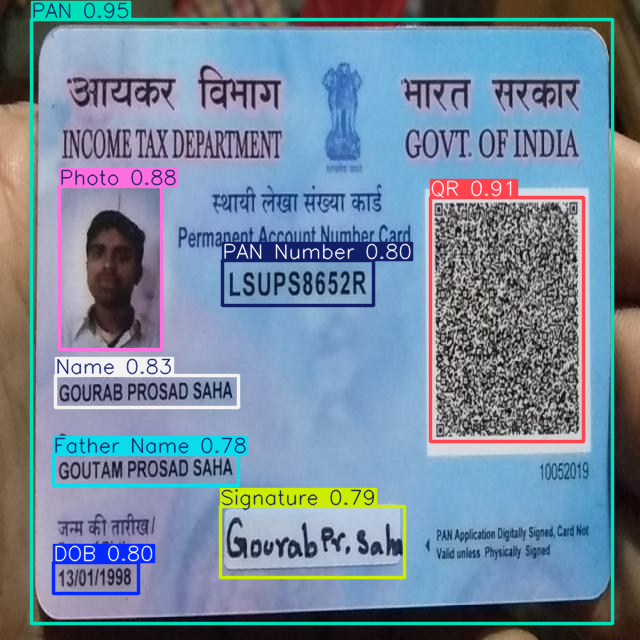

In [6]:
results = model.predict(source=f"/content/PAN_OCR_Detection_Main-1/test/images", conf=0.25)
results[4].show()

In [7]:
model=YOLO("/content/PAN_OCR/yolov12_run/weights/best.pt")

print("=== Model Validation on Test Set ===")
validation_results = model.val(
    data="/content/PAN_OCR_Detection_Main-1/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device="cuda",
    save_json=True,
    save_hybrid=False,
    conf=0.25,
    iou=0.6,
    plots=True
)

print(f"mAP50: {validation_results.box.map50:.4f}")
print(f"mAP50-95: {validation_results.box.map:.4f}")
print(f"Precision: {validation_results.box.mp:.4f}")
print(f"Recall: {validation_results.box.mr:.4f}")

=== Model Validation on Test Set ===
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in in the future.
Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,558,288 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 958.7±613.4 MB/s, size: 64.4 KB)


val: Scanning /content/PAN_OCR_Detection_Main-1/test/labels... 86 images, 0 backgrounds, 0 corrupt: 100%|██████████| 86/86 [00:00<00:00, 1823.90it/s]

val: New cache created: /content/PAN_OCR_Detection_Main-1/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.33it/s]


                   all         86        640      0.984      0.991      0.986      0.753
                   DOB         85         85      0.988          1      0.988      0.631
           Father Name         80         80      0.987          1      0.983      0.669
                  Name         84         84      0.971      0.976      0.975      0.656
                   PAN         86         86          1          1      0.995      0.978
            PAN Number         84         84      0.988          1      0.984      0.661
                 Photo         85         85          1          1      0.995      0.872
                    QR         71         72          1      0.986      0.992      0.922
             Signature         63         64      0.939      0.969      0.973      0.633
Speed: 7.9ms preprocess, 14.6ms inference, 0.0ms loss, 5.9ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val
mAP50: 0.9856
mAP50-95: 0.7526
Precision